--- Generating Data ---
Dataset saved to '../data/student_data.csv'

--- Visualizing Data ---


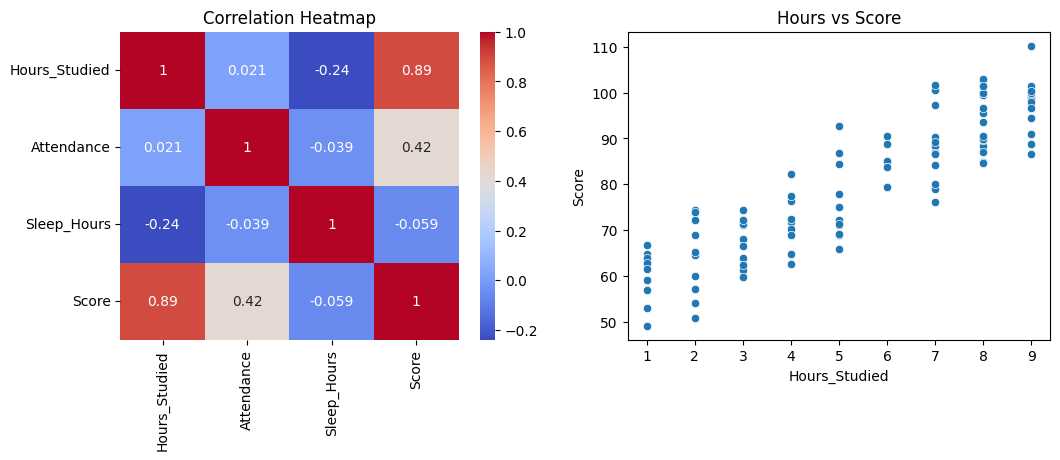

--- Training Model ---
Model Performance (R2): 0.9827
Mean Squared Error: 4.3131

SUCCESS: 'model.pkl' created at c:\Users\User-1\Desktop\Ai&Ds\model.pkl


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. SETUP DIRECTORIES
os.makedirs('../data', exist_ok=True)

# 2. GENERATE SYNTHETIC DATA
print("--- Generating Data ---")
np.random.seed(42)
n_samples = 100
data = {
    'Hours_Studied': np.random.randint(1, 10, n_samples),
    'Attendance': np.random.randint(60, 100, n_samples),
    'Sleep_Hours': np.random.randint(5, 9, n_samples),
}
# Score formula: (Hours * 5) + (Attendance * 0.5) + (Sleep * 2) + Noise
data['Score'] = (data['Hours_Studied'] * 5) + (data['Attendance'] * 0.5) + \
                (data['Sleep_Hours'] * 2) + np.random.normal(0, 2, n_samples)

df = pd.DataFrame(data)
df.to_csv('../data/student_data.csv', index=False)
print("Dataset saved to '../data/student_data.csv'")

# 3. EXPLORATORY DATA ANALYSIS (Quick Visuals)
print("\n--- Visualizing Data ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=ax1)
ax1.set_title("Correlation Heatmap")
sns.scatterplot(data=df, x='Hours_Studied', y='Score', ax=ax2)
ax2.set_title("Hours vs Score")
plt.show()

# 4. MODEL TRAINING
print("--- Training Model ---")
X = df.drop('Score', axis=1)
y = df['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 5. EVALUATION
predictions = model.predict(X_test)
print(f"Model Performance (R2): {r2_score(y_test, predictions):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, predictions):.4f}")

# 6. EXPORTING THE MODEL
# We save this to the parent directory so app.py (in the root) can access it easily.
model_path = '../model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(model, file)

print(f"\nSUCCESS: 'model.pkl' created at {os.path.abspath(model_path)}")